# United States — Full Piotroski F-Score Study (formations 2023–2025)

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** SEC EDGAR XBRL fundamentals (FY2009 onward — XBRL was mandated 2009-2011, which is why the proposal's 2000 start is not reachable from free filings) with **true 10-K filing dates** as `report_date`, so a 1-month buffer replaces the blanket 5-month lag. Universe membership is the S&P 500 list **as of each formation date** (historical constituents dataset), removing index-inclusion look-ahead; names whose price history has vanished from Yahoo (many delistings) still drop out — the residual survivorship is documented in the README. Formations run **July 2011 .. July 2025**, and the evaluation window is capped at **2025-12-31** to stay inside the proposal's 2000–2025 sample (the final formation contributes a half holding year).

Run `python scripts/fetch_us_edgar.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)

MARKET = "us"
YEARS = list(range(2011, 2026))
LAG_MONTHS = 1  # report_date = true 10-K filing date
END_CAP = pd.Timestamp("2025-12-31")  # proposal sample ends in 2025
fund, prices, sectors, bench = load_cached(MARKET, ROOT / "data")
from fscore.data.edgar import load_membership
membership = load_membership(ROOT / "data")
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 586 tickers, FY2006–FY2025
prices: 614 tickers, 2008-01-02 → 2026-07-17


fiscal_year
2006      1
2007      5
2008    261
2009    430
2010    478
2011    496
2012    504
2013    518
2014    527
2015    533
2016    538
2017    545
2018    557
2019    565
2020    570
2021    574
2022    579
2023    584
2024    586
2025    582
Name: statements, dtype: int64

### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

In [2]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  membership=membership, end_cap=END_CAP, seed=42)
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,k,fscore_mean,fscore_basket_min
year,,,,,,
2011,143,57,57,30,6.315789,6
2012,150,60,60,30,6.133333,6
2013,150,60,60,30,5.516667,6
2014,150,60,60,30,5.833333,6
2015,150,60,59,30,5.983051,6
2016,150,60,60,30,5.266667,5
2017,150,60,59,30,5.474576,6
2018,150,60,60,30,5.700000,6
2019,150,60,53,30,6.301887,6


### 2. F-Score distribution within the value universe, per formation

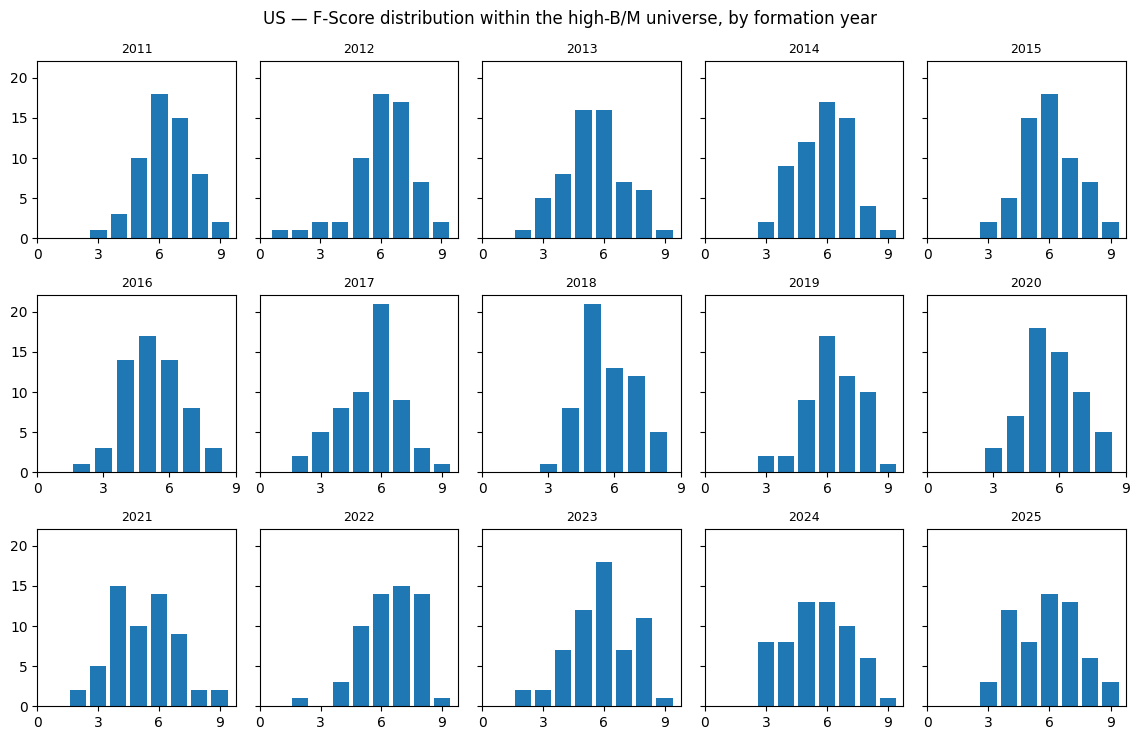

,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,57.00,60.00,60.00,60.00,59.00,60.00,59.00,60.00,53.00,58.00,59.00,58.00,60.00,59.00,59.00
mean,6.32,6.13,5.52,5.83,5.98,5.27,5.47,5.70,6.30,5.64,5.25,6.45,5.87,5.53,5.88
std,1.27,1.53,1.51,1.33,1.37,1.33,1.51,1.23,1.32,1.29,1.60,1.37,1.59,1.59,1.59
min,3.00,1.00,2.00,3.00,3.00,2.00,2.00,3.00,3.00,3.00,2.00,2.00,2.00,3.00,3.00
25%,6.00,5.00,5.00,5.00,5.00,4.00,4.50,5.00,6.00,5.00,4.00,6.00,5.00,4.00,4.50
50%,6.00,6.00,5.50,6.00,6.00,5.00,6.00,5.50,6.00,6.00,5.00,7.00,6.00,6.00,6.00
75%,7.00,7.00,6.00,7.00,7.00,6.00,6.00,7.00,7.00,6.75,6.00,7.75,7.00,7.00,7.00
max,9.00,9.00,9.00,9.00,9.00,8.00,9.00,8.00,9.00,8.00,9.00,9.00,9.00,9.00,9.00


In [3]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

Both benchmarks are USD, like the portfolios.

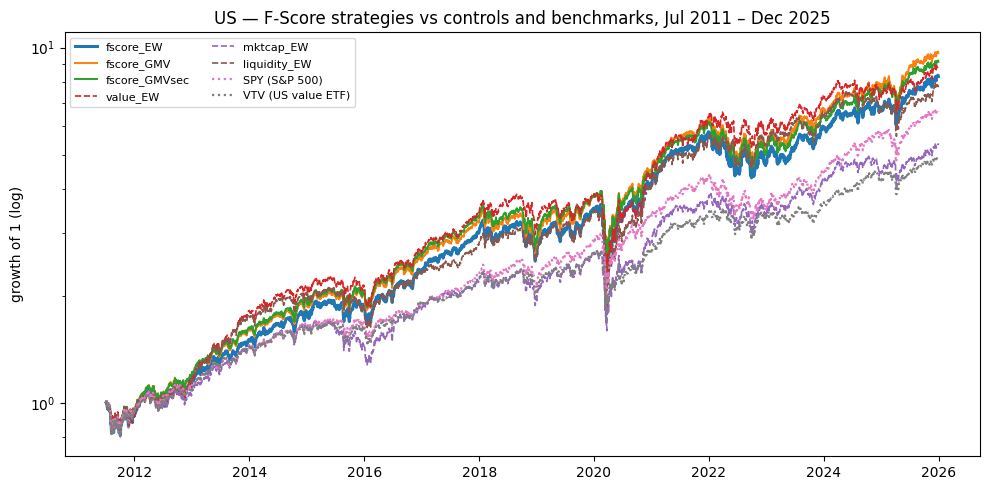

In [4]:
BENCH = {"SPY (S&P 500)": "SPY",
         "VTV (US value ETF)": "VTV"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles[s]
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

In [5]:
tbl = study.summary()
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)
tbl.round(3)

,cum_return,ann_return,ann_vol,sharpe,max_drawdown
fscore_EW,7.290,0.158,0.201,0.784,-0.404
fscore_GMV,8.662,0.170,0.200,0.852,-0.388
fscore_GMVsec,8.121,0.166,0.195,0.851,-0.400
value_EW,7.781,0.163,0.212,0.766,-0.460
mktcap_EW,4.316,0.123,0.191,0.642,-0.404
liquidity_EW,6.736,0.152,0.208,0.731,-0.468
SPY (S&P 500),5.600,0.139,0.173,0.806,-0.337
VTV (US value ETF),3.879,0.116,0.165,0.703,-0.368


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; p-value is one-sided.

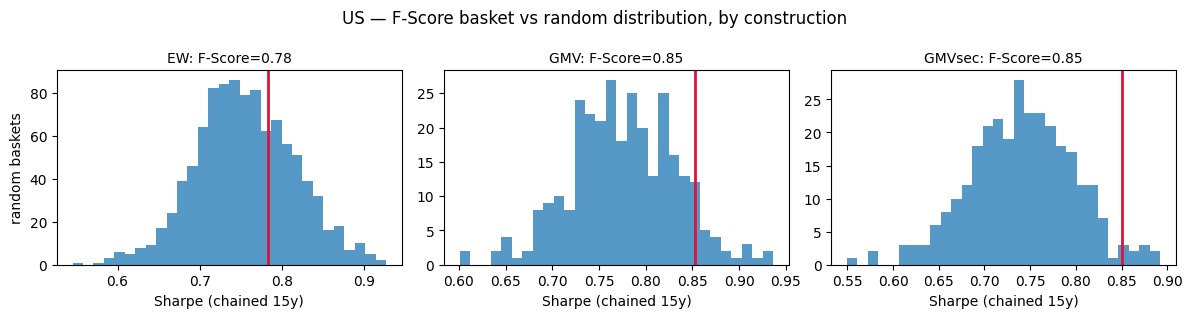

fscore  random_mean  random_std  percentile  \
fscore_EW     ann_return     0.158        0.154       0.012       0.641   
              sharpe         0.784        0.755       0.060       0.687   
              max_drawdown  -0.404       -0.434       0.025       0.891   
fscore_GMV    ann_return     0.170        0.154       0.011       0.940   
              sharpe         0.852        0.776       0.057       0.930   
              max_drawdown  -0.388       -0.424       0.025       0.940   
fscore_GMVsec ann_return     0.166        0.146       0.010       0.970   
              sharpe         0.851        0.740       0.057       0.970   
              max_drawdown  -0.400       -0.431       0.025       0.887   

                            p_value  n_draws  
fscore_EW     ann_return      0.359   1000.0  
              sharpe          0.313   1000.0  
              max_drawdown    0.109   1000.0  
fscore_GMV    ann_return      0.060    300.0  
              sharpe          0.070    300.0  
              max_drawdown    0.060    300.0  
fscore_GMVsec ann_return      0.030    300.0  
              sharpe          0.030    300.0  
              max_drawdown    0.113    300.0

In [6]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 5. Turnover and implied trading cost

One-way turnover between consecutive annual rebalances; cost drag assumes
20 bp per side (2 x turnover x 20 bp per year).

In [7]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,mean,annual cost drag
fscore_EW,0.667,0.667,0.500,0.433,0.633,0.367,0.533,0.467,0.667,0.467,0.567,0.500,0.667,0.567,0.550,0.0022
fscore_GMV,0.701,0.687,0.574,0.558,0.664,0.441,0.648,0.484,0.643,0.485,0.562,0.562,0.785,0.693,0.606,0.0024
fscore_GMVsec,0.738,0.697,0.571,0.565,0.694,0.428,0.648,0.495,0.644,0.499,0.559,0.583,0.825,0.665,0.615,0.0025
value_EW,0.300,0.200,0.200,0.167,0.333,0.300,0.233,0.400,0.333,0.233,0.267,0.300,0.233,0.333,0.274,0.0011
mktcap_EW,0.233,0.233,0.233,0.300,0.333,0.333,0.233,0.300,0.233,0.267,0.267,0.367,0.233,0.367,0.281,0.0011
liquidity_EW,0.667,0.667,0.633,0.533,0.700,0.433,0.633,0.800,0.733,0.567,0.700,0.700,0.700,0.500,0.640,0.0026


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on the Fama-French three factors (market,
size, value) with Newey-West standard errors.

In [8]:
ff = fetch_ff_factors("us")
series = {s: study.daily[s].dropna()
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,0.0001,0.0206,1.1919,0.2333,1.0492,0.0778,0.1790,0.8934,3636.0
fscore_GMV,0.0001,0.0292,1.8281,0.0675,1.0539,0.0410,0.1355,0.9036,3636.0
value_EW,0.0001,0.0238,1.2238,0.2210,1.0851,0.1290,0.2583,0.8812,3636.0


In [9]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to C:\Users\miked\OneDrive\Desktop\Career\WQU\Cap Project\fscore_capstone\results


### 7. Reading the results

**Selection alone is positive but not decisive.** Over 15 chained formations
(Jul 2011 – Dec 2025) the equal-weight F-Score basket earns 15.8% p.a.
(Sharpe 0.78) and lands at the **64–69th percentile** of 1,000 random
same-universe baskets (one-sided p ≈ 0.31–0.36): better than chance, but not
significantly so on its own. It does beat the size control (12.3%) and the
liquidity-matched control (15.2%), and it edges the pure value screen on
Sharpe (0.78 vs 0.77) with a visibly shallower drawdown (−40% vs −46%,
89th percentile of the random distribution).

**Construction is where the signal becomes significant — the synergy the
proposal set out to test.** Running the *same* baskets through RMT-cleaned
GMV lifts the F-Score portfolio to 17.0% p.a. (Sharpe 0.85), and against
random baskets pushed through the *identical* GMV pipeline it sits at the
**93–94th percentile (p ≈ 0.06–0.07)**; sector-capped GMV reaches the
**97th percentile (p ≈ 0.03)**. Optimization helps the F-Score basket more
than it helps random baskets — consistent with covariance cleaning being most
valuable when the underlying names are fundamentally sound.

**Practicality.** All F-Score variants beat buy-and-hold SPY (13.9%) and the
value ETF VTV (11.6%) over the window, at ~0.55–0.62 annual one-way turnover
(≈ 22–25 bp cost drag at 20 bp per side). The FF3 regression leaves an
annualized alpha of 2.1% (t = 1.19, n.s.) for EW and **2.9% (t = 1.83,
p ≈ 0.07)** for GMV, with the expected value loading (HML ≈ 0.14–0.18) —
the edge is not just repackaged factor exposure, but it is marginal.

**Caveats.** FY2009 is EDGAR XBRL's floor, so 2000–2008 (incl. the GFC
drawdown for value) is out of reach from free filings; membership is
point-in-time but names whose price history is gone from Yahoo drop out
(residual survivorship, 173 of 787 historical members); market caps use
cover-page share counts. Within those limits, every formation uses only
information filed before it.